# measure

> Perform profile measurement on cluster images

In [ ]:
# | default_exp euclid.measure

In [ ]:
# | exporti

import logging
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits

from nicl.autoprof import Extract_SB_using_AP_shapes, create_bkgsub_images, run_autoprof
from nicl.euclid.mask import (
    ICL_BKG_FILTER_SIZE,
    create_combined_nir_mask,
    create_vis_mask,
)
from nicl.euclid.utilities import default_data_path
from nicl.main import configure_logging

In [ ]:
# | exporti


def mpc_to_pixels(z, pixel_scale_arcsec=0.3, physical_mpc=1.0):
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    arcsec_per_kpc = cosmo.arcsec_per_kpc_proper(z).value  # arcsec/kpc
    arcsec_per_mpc = arcsec_per_kpc * 1000  # arcsec/Mpc
    pixels_per_mpc = arcsec_per_mpc / pixel_scale_arcsec
    return pixels_per_mpc * physical_mpc

In [ ]:
# | export


def process_cluster_pipeline(
    image_dir,
    outdir,
    cluster_ids,
    filters,  # filter for detection image
    mask_filter=None,  # filter for mask that will be applied on detection image
    mask_prefix=None,  # if certain mask parameters are changed and wanted to take a different name (useful during tests).
    cluster_info_table=None,
    cluster_z=None,
    pixelscale=0.3,
    bcg_pos=None,  # Skycoord object
    mock_image=False,
    masking=True,
    image_prefix=None,
    other_prefix=None,
    box_size=None,  # NIR_STACK_BKG_BOX_SIZE, ICL_BKG_BOX_SIZE and ns in background calcualtion
    run_autoprof_function=True,
    SB_extraction=False,
    show_profiles=False,
    forced_photometry=False,
    forced_profile_filter=None,  # filter of detection image from which the shapes are being used from
    forced_profile_path=None,
    external_mask_path=None,
    external_bkg_mask_path=None,
    noise_file_path=None,
):
    logger = logging.getLogger(__name__)
    image_dir = Path(image_dir)
    outdir = Path(outdir)

    for cluster_id in cluster_ids:
        cluster_output_dir = outdir / cluster_id
        cluster_output_dir.mkdir(parents=True, exist_ok=True)

        if not mock_image:
            if cluster_info_table is not None:
                cluster_info = cluster_info_table[
                    cluster_info_table.Label_ID == cluster_id
                ].reset_index(drop=True)
                cluster_z = cluster_info.BEST_Z[0]
                bcg_pos = SkyCoord(
                    cluster_info.RA_BCG[0] * u.deg,
                    cluster_info.DEC_BCG[0] * u.deg,
                    frame="icrs",
                )
            else:
                cluster_z = cluster_z
                bcg_pos = bcg_pos
        else:
            cluster_z = 0.1
            bcg_pos = None

        logger.info(
            f"Cluster id: {cluster_id}, redshift: {cluster_z}, BCG coords: {bcg_pos}"
        )

        if box_size is None:
            logger.debug(
                "Calculating the redshift dependent box size for background calculation in pixels for 1Mpc..."
            )
            if cluster_z is None:
                raise ValueError("z needs to be provided to calculate 1 Mpc boxsize")
            else:
                box_size = int(
                    mpc_to_pixels(z=cluster_z, pixel_scale_arcsec=pixelscale)
                )
                logger.info(
                    f'1 Mpc at z={cluster_z} corresponds to {box_size} pixels at {pixelscale}"/px.'
                )

                NIR_STACK_BKG_BOX_SIZE = box_size
                ICL_BKG_BOX_SIZE = box_size

        if isinstance(filters, str):
            filters = [filters]

        for filter in filters:
            logger.info(
                f"Using {filter} band image and {mask_filter} band mask for {cluster_id}"
            )

            ### Below, additional labelling prefix refers to label that image file contains,
            ### e.g. a mock cluster image is called "cluster0_with_skypatchnoise.fits" --"with_skypatchnoise" is the image_prefix.
            ### other_prefix is the extra label for tests within changes in pipeline not changes in input image,
            ### e.g., cluster0_with_skypatchnoise_APgscale0.2.prof is using cluster0_with_skypatchnoise.fits
            ### but gscale is changed within AP, mask and input images are the same.
            ### if any cahgnes in mask, mask_prefix should be included. e.g.  cluster0_with_skypatchnoise_fgrowth0.5.prof growth is increased to 0.5 from default value 0.25 in faint masking so mask_prefix is "faintgrowth0.5"

            image_label = f"{cluster_id}_{filter}"

            if image_prefix:
                image_label += f"_{image_prefix}"

            # Constructing the image and mask paths...

            mask_file_output_label = (
                f"{cluster_id}_{image_prefix}" if image_prefix else f"{cluster_id}"
            )

            if mask_filter is None:
                final_output_label = f"{image_label}_nomask"
            else:
                masking = True
                mask_label = f"{mask_filter}"
                if mask_prefix:
                    mask_label += f"_{mask_prefix}"
                    mask_file_output_label += f"_{mask_prefix}"
                final_output_label = f"{image_label}_{mask_label}"
                if mask_filter in ["H", "J", "Y", "YJH"]:
                    default_mask_path = (
                        cluster_output_dir
                        / f"{mask_file_output_label}_NIR_measurement_mask.fits"
                    )
                    default_bkg_mask_path = (
                        cluster_output_dir
                        / f"{mask_file_output_label}_NIR_background_mask.fits"
                    )
                elif mask_filter == "VIS":
                    default_mask_path = (
                        cluster_output_dir
                        / f"{mask_file_output_label}_VIS_measurement_mask.fits"
                    )
                    default_bkg_mask_path = (
                        cluster_output_dir
                        / f"{mask_file_output_label}_VIS_background_mask.fits"
                    )
                else:
                    raise ValueError(f"Unknown mask filter: {mask_filter}")

            if filter in ["H", "J", "Y"]:
                image_filename = (
                    f"{image_label}.fits"
                    if mock_image
                    else f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"
                )
                fn = image_dir / image_filename
            elif filter == "YJH":
                image_filename = (
                    f"{cluster_id}_{image_prefix}_NIR_YJH_coadded.fits"
                    if image_prefix
                    else f"{cluster_id}_NIR_YJH_coadded.fits"
                )
                fn = cluster_output_dir / image_filename
            elif filter in ["VIS"]:
                image_filename = (
                    f"{image_label}.fits"
                    if mock_image
                    else f"EUC_VIS_SWL-STK-{cluster_id}.fits"
                )
                fn = image_dir / image_filename

            if masking:
                logger.info(f"Processing image {fn}")
                logger.info(f"Measurement mask is {default_mask_path}")
                logger.info(f"Background mask is {default_bkg_mask_path}")

                if not default_mask_path.exists() or not default_bkg_mask_path.exists():
                    if mask_filter in ["H", "J", "Y", "YJH"]:
                        logger.info("Creating new NIR masks...")
                        if mock_image:
                            suffix = f"_{image_prefix}" if image_prefix else ""
                            image_H = image_dir / f"{cluster_id}_H{suffix}.fits"
                            image_J = image_dir / f"{cluster_id}_J{suffix}.fits"
                            image_Y = image_dir / f"{cluster_id}_Y{suffix}.fits"
                        else:
                            image_H = image_dir / f"EUC_NIR_W-STK_H-{cluster_id}.fits"
                            image_J = image_dir / f"EUC_NIR_W-STK_J-{cluster_id}.fits"
                            image_Y = image_dir / f"EUC_NIR_W-STK_Y-{cluster_id}.fits"

                        create_combined_nir_mask(
                            str(image_H),
                            str(image_J),
                            str(image_Y),
                            centre_pos=bcg_pos,
                            redshift=cluster_z,
                            filter=filter,
                            label=mask_file_output_label,
                            output_dir=str(cluster_output_dir),
                            ICL_BKG_BOX_SIZE=ICL_BKG_BOX_SIZE,
                            NIR_STACK_BKG_BOX_SIZE=NIR_STACK_BKG_BOX_SIZE,
                        )
                        logger.info("Created NIR masks!")

                    elif mask_filter == "VIS":
                        logger.info("Creating new VIS masks...")

                        create_vis_mask(
                            str(fn),
                            centre_pos=bcg_pos,
                            redshift=cluster_z,
                            filter=filter,
                            label=mask_file_output_label,
                            ICL_BKG_BOX_SIZE=ICL_BKG_BOX_SIZE,
                            output_dir=str(cluster_output_dir),
                        )
                        logger.info("Created VIS mask!")

                    else:
                        raise ValueError(f"Unknown mask filter: {mask_filter}")

            else:
                logger.info(
                    "Measurement and Background masks already exist. Skipping creation."
                )

            AP_results_dir = cluster_output_dir / "autoprof_results"
            AP_results_dir.mkdir(parents=True, exist_ok=True)

            if masking:
                mask_path = (
                    Path(external_mask_path)
                    if external_mask_path is not None
                    else default_mask_path
                )
                bkg_mask_path = (
                    Path(external_bkg_mask_path)
                    if external_bkg_mask_path is not None
                    else default_bkg_mask_path
                )

                if not mask_path.exists() or not bkg_mask_path.exists():
                    raise FileNotFoundError(
                        f"Expected mask not found at {mask_path} or {bkg_mask_path}"
                    )

                temp_cleaned_dir = cluster_output_dir / "temp_cleaned"
                temp_cleaned_dir.mkdir(exist_ok=True)

                logger.info(f"Creating background with boxsize {box_size}")

                cleaned_paths = create_bkgsub_images(
                    image_paths={filter: str(fn)},
                    background_mask_path=str(bkg_mask_path),
                    output_background_dir=cluster_output_dir,
                    temp_cleaned_dir=temp_cleaned_dir,
                    label=final_output_label,
                    clean_nans=True,
                    box_size=box_size,
                    filter_size=ICL_BKG_FILTER_SIZE,
                )

                cleaned_image_path = cleaned_paths[filter]

            else:
                with fits.open(fn) as hdul:
                    hdu_index = 1 if len(hdul) > 1 else 0
                    image_data = hdul[hdu_index].data
                    image_header = hdul[hdu_index].header

                image_data_cleaned = np.where(~np.isfinite(image_data), 99, image_data)
                cleaned_image_path = cluster_output_dir / f"cleaned_{image_label}.fits"
                fits.writeto(
                    cleaned_image_path,
                    image_data_cleaned,
                    header=image_header,
                    overwrite=True,
                )

            if forced_photometry:
                if forced_profile_filter is not None:
                    logger.info(
                        f"The elliptical shapes will be taken from detection in {forced_profile_filter} band"
                    )
                    final_output_label += f"_{forced_profile_filter}"
                else:
                    raise ValueError(
                        "forced_profile_filter should be provided for forced_photometry=True"
                    )
            else:
                forced_profile_filter = filter
                final_output_label += f"_{forced_profile_filter}"
                logger.info(
                    f"The elliptical shapes will be taken from detection in {forced_profile_filter} band"
                )

            if other_prefix:
                final_output_label += f"_{other_prefix}"

            if run_autoprof_function:
                logger.info(
                    f"Autoprof running on {cleaned_image_path}, with mask {mask_path.name if masking else 'None'} ..."
                )

                run_autoprof(
                    ids=[final_output_label],
                    image_files=[str(cleaned_image_path)],
                    mask_files=[str(mask_path)] if masking else None,
                    out_dir=str(AP_results_dir),
                    forced_photometry=forced_photometry,
                    forced_profile_filter=forced_profile_filter,
                    forced_profile_path=str(forced_profile_path)
                    if forced_photometry
                    else None,
                )

                ###### Cleaning some of the excess diagnostic plots ....

                always_keep = {"basic_config.py", "AutoProf.log"}
                jpg_keywords_to_keep = [
                    "mask_",
                    "initialize_ellipse_",
                    "photometry_",
                    "photometry_ellipse_",
                ]
                valid_suffixes_to_keep = [".prof", ".aux"]

                for f in AP_results_dir.iterdir():
                    if f.is_file():
                        name = f.name
                        if name in always_keep:
                            continue
                        if any(
                            name.endswith(suffix) for suffix in valid_suffixes_to_keep
                        ):
                            continue
                        if name.endswith(".jpg") and any(
                            kw in name for kw in jpg_keywords_to_keep
                        ):
                            continue
                        try:
                            f.unlink()
                            logger.debug(f"Deleted: {name}")
                        except Exception as e:
                            logger.warning(f"Could not delete {name}: {e}")

            if SB_extraction:
                if masking:
                    logger.info(f"Creating background with boxsize {box_size}")

                    cleaned_paths = create_bkgsub_images(
                        image_paths={filter: str(fn)},
                        background_mask_path=str(bkg_mask_path),
                        output_background_dir=cluster_output_dir,
                        temp_cleaned_dir=temp_cleaned_dir,
                        label=final_output_label,
                        savebkg=False,
                        clean_nans=False,
                        box_size=box_size,
                        filter_size=ICL_BKG_FILTER_SIZE,
                    )

                    cleaned_image_path = cleaned_paths[filter]

                logger.info(
                    f"Extracting SB profile for {cluster_id} in {filter} with masking {mask_filter} band detection and shapes from {forced_profile_filter} band results.."
                )

                prof_filename = f"{final_output_label}.prof"
                prof_path = AP_results_dir / prof_filename

                image_path = cleaned_image_path

                flux_measurements, profile, problematic_annuli, AP_background_level = (
                    Extract_SB_using_AP_shapes(
                        image_path=image_path,
                        object_mask_path=str(mask_path) if masking else None,
                        profile_path=prof_path,
                        bcg_pos=bcg_pos,
                        plot_output_path=cluster_output_dir,
                        prefix=final_output_label,
                        add_in_AP_background_level=True,
                    )
                )

                flux_outfile = (
                    cluster_output_dir
                    / f"{final_output_label}_profile_measurements.csv"
                )
                flux_measurements.to_csv(flux_outfile, index=False)

                # Reading .prof file to merge isophote, annulus method results and the noise curves
                with open(prof_path) as f:
                    units_line = f.readline().strip()
                    column_line = f.readline().strip()
                    unit_list = units_line.lstrip("#").split(",")
                    column_list = column_line.split(",")
                    data_df = pd.read_csv(f, names=column_list)

                # Adding flux measurement columns
                data_df["SMA_annulus_centre"] = flux_measurements[
                    "SMA_annulus_centre_arcsec"
                ]
                data_df["Median_flux_annulus"] = flux_measurements[
                    "Clipped_median_flux_annulus"
                ]

                # Loading noise file and finding appropriate box sized one...
                if noise_file_path is not None:
                    noise_bkg_sizes = np.array(
                        [450, 500, 550, 650, 750, 1000, 1800, 2350]
                    )
                    idx = (np.abs(noise_bkg_sizes - box_size)).argmin()
                    closest_bs = noise_bkg_sizes[idx]
                    logger.info(
                        f"1 Mpc at cluster corresponds to {box_size} and closest box size used in noise measurements is: {closest_bs}"
                    )

                    noise_file = (
                        noise_file_path
                        / f"Skypatch_bs{closest_bs}_{filter}_noise_measurements.csv"
                    )

                    if noise_file.exists():
                        noise_df = pd.read_csv(noise_file)
                    else:
                        logger.warning(
                            f"Noise file {noise_file.name} not found. Creating dummy noise data filled with zeros."
                        )
                        n_rows = len(data_df)
                        noise_df = pd.DataFrame(
                            {
                                "SMA_annulus_centre_noise": np.zeros(n_rows),
                                "MAD_median_clipped_flux_noise": np.zeros(n_rows),
                                "MAD_bkg_subtracted_flux_noise": np.zeros(n_rows),
                            }
                        )

                    # Adding noise columns
                    data_df["SMA_annulus_centre_noise"] = noise_df[
                        "SMA_annulus_centre_arcsec"
                    ]
                    data_df["MAD_median_clipped_flux_noise"] = noise_df[
                        "MAD_Median_Clipped_Flux"
                    ]
                    data_df["MAD_bkg_subtracted_flux_noise"] = noise_df[
                        "MAD_Bkg_Subtracted_Flux"
                    ]

                # Cleaning nans for Autoprof, it hates nans
                data_df.fillna(0, inplace=True)

                # Adding back AP background level which is subtracted within their framework
                data_df["I"] = data_df["I"] + AP_background_level

                # Unit and column lists
                # FIXME: This would be more straightforward if we used an astropy table, rather than a pandas dataframe
                new_cols = ["SMA_annulus_centre", "Median_flux_annulus"]
                new_units = ["arcsec", "flux*arcsec^-2"]
                if noise_file_path is not None:
                    new_cols += [
                        "SMA_annulus_centre_noise",
                        "MAD_median_clipped_flux_noise",
                        "MAD_bkg_subtracted_flux_noise",
                    ]
                    new_units += ["arcsec", "flux*arcsec^-2", "flux*arcsec^-2"]
                for col, unit in zip(new_cols, new_units):
                    if col not in column_list:
                        column_list.append(col)
                        unit_list.append(unit)

                # Updating the .prof file...
                with open(prof_path, "w") as f:
                    f.write("#" + ",".join(unit_list) + "\n")
                    f.write(",".join(column_list) + "\n")
                    data_df.to_csv(f, index=False, header=False)

                logger.info(
                    "Final updated .prof file with SB + Noise written successfully."
                )

                if show_profiles:
                    fig, ax = plt.subplots(1, 1)
                    ax.plot(
                        data_df["SMA_annulus_centre"],
                        data_df["Median_flux_annulus"],
                        color="tab:green",
                        label="Median Flux Annuli",
                    )
                    ax.plot(
                        data_df["R"],
                        data_df["I"],
                        color="tab:blue",
                        label="Median Flux Isophote",
                    )

                    ax.set_ylabel(r"Surface Brightness ($\rm flux \ arcsec^{-2}$)")
                    ax.set_xlabel("semi-major axis (arcsec)")
                    ax.set_yscale("log")
                    ax.set_xscale("log")
                    fig_path = cluster_output_dir / f"SB_comparisons_{image_label}.pdf"
                    plt.legend(loc="upper right", fontsize=10)
                    plt.savefig(fig_path, dpi=100)
                    plt.show()

                    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
                    ax[0].errorbar(
                        data_df["R"],
                        data_df["ellip"],
                        yerr=data_df["ellip_e"],
                        color="tab:blue",
                    )
                    ax[0].set_ylim(0, 1)
                    ax[0].set_ylabel("Ellipticity")
                    ax[1].errorbar(
                        data_df["R"],
                        data_df["pa"],
                        yerr=data_df["pa_e"],
                        color="tab:blue",
                    )
                    ax[1].set_ylim(0, 180)
                    ax[1].set_ylabel("Position Angle [deg]")

                    for a in fig.get_axes():
                        a.set_xlabel("semi-major axis (arcsec)")

                    fig_path = cluster_output_dir / f"Shapes_{image_label}.pdf"
                    plt.show()

## Examples

In [ ]:
configure_logging(name="__main__", level="DEBUG")
configure_logging(name="nicl.euclid.mask", level="DEBUG")
configure_logging(name="nicl.mask", level="DEBUG")

<Logger nicl.mask (DEBUG)>

### Mock clusters

2025-05-08 00:39:47 - __main__.process_cluster_pipeline - INFO - Cluster information:
 id: cluster0
 redshift: 0.1
 BCG coords: None
2025-05-08 00:39:47 - __main__.process_cluster_pipeline - DEBUG - Calculating the redshift dependent box size for background calculation in pixels for 1Mpc...
2025-05-08 00:39:47 - __main__.process_cluster_pipeline - INFO - 1 Mpc at z=0.1 corresponds to 1807 pixels at 0.3"/px.
2025-05-08 00:39:47 - __main__.process_cluster_pipeline - INFO - Using H band image and YJH band mask for cluster0
2025-05-08 00:39:47 - __main__.process_cluster_pipeline - INFO - Processing image /home/ppzjbg/JGM_Tests/Mock_Images/cluster0_H_skypatch_field.fits.
2025-05-08 00:39:47 - __main__.process_cluster_pipeline - INFO - Measurement mask is /home/ppzsb1/euclid_data/Q1_R1_clusters_v0.7/analysis/TK/mock_tests/cluster0/cluster0_skypatch_field_NIR_measurement_mask.fits.
2025-05-08 00:39:47 - __main__.process_cluster_pipeline - INFO - Background mask is /home/ppzsb1/euclid_data/Q1_

<Logger __main__ (DEBUG)> 10
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-05-08 00:39:47 - nicl.mask.create_bcg_mask - INFO - Creating BCG mask
2025-05-08 00:39:48 - nicl.mask.get_label_at_position - DEBUG - Determining label at pixel index [2999 2999]
2025-05-08 00:39:48 - nicl.mask.keep_segment_at_position - DEBUG - Keeping segment with label 6832
2025-05-08 00:39:49 - nicl.mask.create_icl_mask - INFO - Creating ICL mask
2025-05-08 00:39:49 - nicl.mask.create_icl_mask - DEBUG - Estimating background with box size 1807 and filter size 3
2025-05-08 00:40:02 - nicl.mask.create_icl_mask - DEBUG - Average 2 sigma detection threshold: 0.04222
2025-05-08 00:40:02 - nicl.mask.create_icl_mask - DEBUG - Smoothing image with sigma=10.0
2025-05-08 00:40:02 - nicl.mask.create_icl_mask - DEBUG - Smoothing with a sampled median filter
2025-05-08 00:40:33 - nicl.mask.create_icl_mask - DEBUG - Detecting sources
2025-05-08 00:40:34 - nicl.mask.create_icl_mask - DEBUG - Initial segmentation map contains 274 sources
2025-05-08 00:40:34 - nicl.mask.create_icl_mask - DEBUG

INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-05-08 00:42:08 - nicl.mask.create_bcg_mask - INFO - Creating BCG mask
2025-05-08 00:42:09 - nicl.mask.get_label_at_position - DEBUG - Determining label at pixel index [2999 2999]
2025-05-08 00:42:09 - nicl.mask.keep_segment_at_position - DEBUG - Keeping segment with label 6009
2025-05-08 00:42:10 - nicl.mask.create_icl_mask - INFO - Creating ICL mask
2025-05-08 00:42:10 - nicl.mask.create_icl_mask - DEBUG - Estimating background with box size 1807 and filter size 3
2025-05-08 00:42:20 - nicl.mask.create_icl_mask - DEBUG - Average 2 sigma detection threshold: 0.04086
2025-05-08 00:42:20 - nicl.mask.create_icl_mask - DEBUG - Smoothing image with sigma=10.0
2025-05-08 00:42:20 - nicl.mask.create_icl_mask - DEBUG - Smoothing with a sampled median filter
2025-05-08 00:42:54 - nicl.mask.create_icl_mask - DEBUG - Detecting sources
2025-05-08 00:42:55 - nicl.mask.create_icl_mask - DEBUG - Initial segmentation map contains 241 sources
2025-05-08 00:42:55 - nicl.mask.create_icl_mask - DEBUG

...

INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-05-08 00:50:25 - __main__.process_cluster_pipeline - INFO - The elliptical shapes will be taken from detection in H band
2025-05-08 00:50:25 - __main__.process_cluster_pipeline - INFO - Autoprof running on /home/ppzsb1/euclid_data/Q1_R1_clusters_v0.7/analysis/TK/mock_tests/cluster0/temp_cleaned/cluster0_H_skypatch_field_YJH_cleaned_bkgsub.fits, with mask cluster0_skypatch_field_NIR_measurement_mask.fits ...
2025-05-08 00:57:00 - __main__.process_cluster_pipeline - DEBUG - Deleted: phase_profile_cluster0_H_skypatch_field_YJH_H.jpg
2025-05-08 00:57:00 - __main__.process_cluster_pipeline - DEBUG - Deleted: fit_ellipse_cluster0_H_skypatch_field_YJH_H.jpg
2025-05-08 00:57:00 - __main__.process_cluster_pipeline - DEBUG - Deleted: Background_hist_cluster0_H_skypatch_field_YJH_H.jpg
2025-05-08 00:57:00 - __main__.process_cluster_pipeline - INFO - Creating background with boxsize 1807
2025-05-08 00:57:00 - astropy.fits_ccddata_reader - INFO - first HDU with data is extension 1.


INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-05-08 00:57:08 - __main__.process_cluster_pipeline - INFO - Extracting SB profile for cluster0 in H with masking YJH band detection and shapes from H band results..
2025-05-08 00:57:08 - astropy.fits_ccddata_reader - INFO - using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


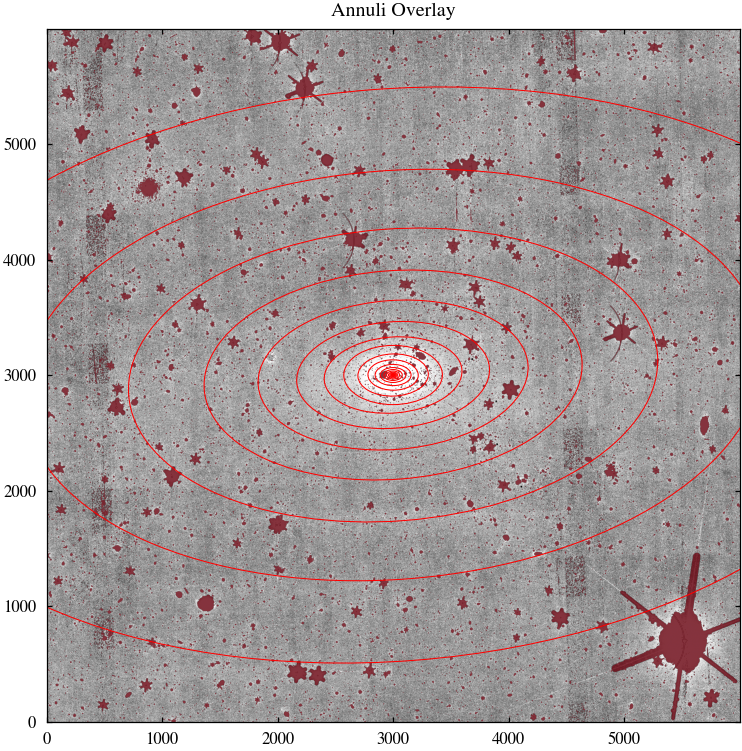

2025-05-08 00:57:37 - __main__.process_cluster_pipeline - INFO - Final updated .prof file with SB + Noise written successfully.


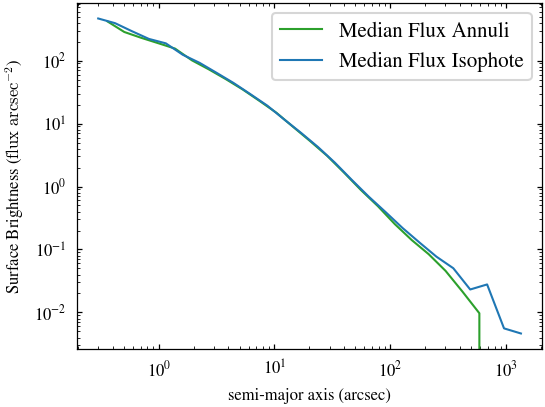

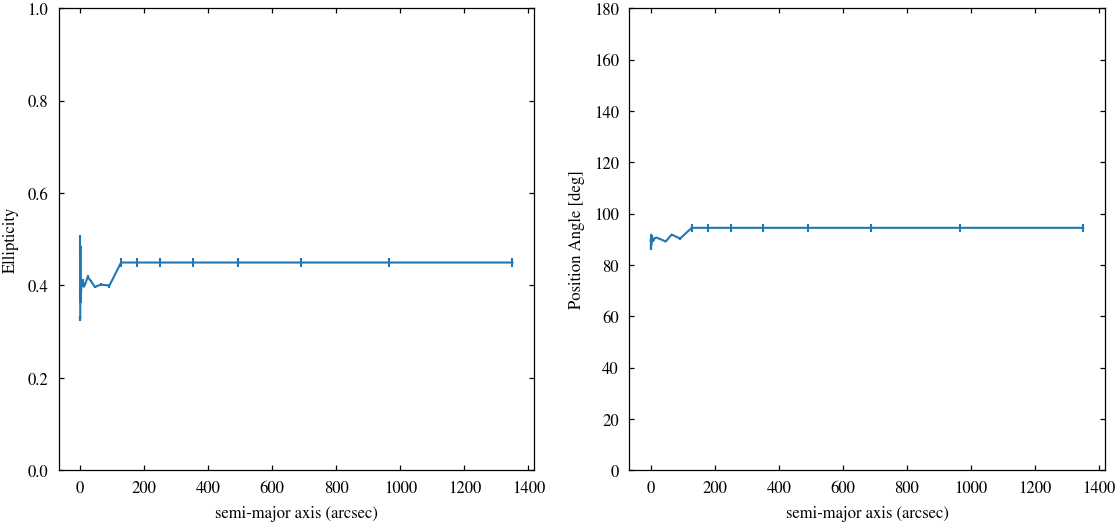

In [ ]:
cluster_ids = ["cluster0"]
outdir_base = default_data_path("Q1_R1_clusters_v0.7/analysis/TK/mock_tests")
image_base = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")

process_cluster_pipeline(
    image_dir=image_base,
    outdir=outdir_base,
    cluster_ids=cluster_ids,
    filters="H",
    mock_image=True,
    masking=True,
    mask_filter="YJH",
    run_autoprof_function=True,
    SB_extraction=True,
    show_profiles=True,
    image_prefix="skypatch_field",
)

In [ ]:
# cluster_ids = ["cluster0", "cluster1", "cluster2"]
# outdir_base = default_data_path("Q1_R1_clusters_v0.7/analysis/TK/mocks")
# image_base = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")

# filters = ["VIS"]

# for filter in filters:
#     if filter in ["H", "J", "Y", "VIS"]:
#         image_dir = image_base
#         outdir = outdir_base

#         process_cluster_pipeline(
#             image_dir=image_dir,
#             outdir=outdir,
#             cluster_ids=cluster_ids,
#             filters=filter,
#             mock_image=True,
#             masking=True,
#             mask_filter="YJH",
#             run_autoprof_function=True,
#             SB_extraction=True,
#             show_profiles=True,
#             image_prefix="skypatch_field",
#         )

#     elif filter == "YJH":
#         for clid in cluster_ids:
#             image_dir = Path(f"/home/ppztk1/Erosita/Outputs_Clusters/{clid}/")
#             outdir = outdir_base

#             process_cluster_pipeline(
#                 image_dir=image_dir,
#                 outdir=outdir,
#                 cluster_ids=[clid],
#                 filters=filter,
#                 mock_image=True,
#                 masking=True,
#                 mask_filter="YJH",
#                 run_autoprof_function=True,
#                 SB_extraction=True,
#                 show_profiles=True,
#                 image_prefix="skypatch_field",
#             )

## Real clusters

In [ ]:
# import os
# os.environ["MKL_NUM_THREADS"] = "10"
# os.environ["NUMEXPR_NUM_THREADS"] = "10"
# os.environ["OMP_NUM_THREADS"] = "10"


# cluster_ids = ["EDFS_eRASS_64", "EDFS_eRASS_63", "EDFS_eRASS_64"]

# # "EDFS_eRASS_65", , "EDFS_eRASS_60", "EDFS_eRASS_63", "EDFS_eRASS_14"
# image_dir = Path("/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/TK/")
# noise_dir = Path("/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/")
# table = pd.read_csv('/home/ppztk1/Erosita/Erosita_EDFS_LargeSample.csv')

# outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")


# filters = ["H", "J", "Y"]
# process_cluster_pipeline(
#     image_dir=image_dir,
#     outdir=outdir,
#     cluster_ids=cluster_ids,
#     cluster_info_table= table,
#     filters=filters,
#     mock_image=False,
#     masking=True,
#     mask_filter="YJH",
#     run_autoprof_function = True,
#     SB_extraction=True,
#     show_profiles = True,
#     noise_file_path = noise_dir
# )


# filters = ["YJH"]
# process_cluster_pipeline(
#     image_dir=image_dir,
#     outdir=outdir,
#     cluster_ids=cluster_ids,
#     cluster_info_table= table,
#     filters=filters,
#     mock_image=False,
#     masking=True,
#     mask_filter="YJH",
#     run_autoprof_function = True,
#     SB_extraction=True,
#     show_profiles = True,
#     noise_file_path = noise_dir
# )

# filters = ["VIS"]
# process_cluster_pipeline(
#     image_dir=image_dir,
#     outdir=outdir,
#     cluster_ids=cluster_ids,
#     cluster_info_table= table,
#     filters=filters,
#     mock_image=False,
#     masking=True,
#     mask_filter="VIS",
#     run_autoprof_function = True,
#     SB_extraction=True,
#     show_profiles = True,
#     noise_file_path = noise_dir

# )

# filters = ["H", "J", "Y"]
# process_cluster_pipeline(
#     image_dir=image_dir,
#     outdir=outdir,
#     cluster_ids=cluster_ids,
#     cluster_info_table= table,
#     filters=filters,
#     mock_image=False,
#     masking=True,
#     mask_filter="YJH",
#     run_autoprof_function = True,
#     SB_extraction=True,
#     noise_file_path = noise_dir,
#     show_profiles = True,
#     forced_photometry=True,
#     forced_profile_filter='YJH',
#     forced_profile_path= '/home/ppztk1/Erosita/Outputs_Clusters/EDFS_eRASS_56/autoprof_results/EDFS_eRASS_56_YJH_YJH_YJH.prof'

# )


# filters = ["VIS"]
# process_cluster_pipeline(
#     image_dir=image_dir,
#     outdir=outdir,
#     cluster_ids=cluster_ids,
#     cluster_info_table= table,
#     filters=filters,
#     mock_image=False,
#     masking=True,
#     mask_filter="VIS",
#     run_autoprof_function = True,
#     SB_extraction=True,
#     noise_file_path = noise_dir,
#     show_profiles = True,
#     forced_photometry=True,
#     forced_profile_filter='YJH',
#     forced_profile_path= '/home/ppztk1/Erosita/Outputs_Clusters/EDFS_eRASS_56/autoprof_results/EDFS_eRASS_56_YJH_YJH_YJH.prof'
#     )
